[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Saving raksha-farmer-query.csv to raksha-farmer-query (1).csv
       StateName DistrictName BlockName  Season        Sector Category  \
0      KARNATAKA     HUBBALLI     PUSAD     NaN  HORTICULTURE   Others   
1    MAHARASHTRA        AKOLA    SAKOLI     NaN  HORTICULTURE   Others   
2    MAHARASHTRA        LATUR     PUSAD     NaN   AGRICULTURE   Others   
3  UTTAR PRADESH      LUCKNOW    SAKOLI     NaN  HORTICULTURE   Others   
4    MAHARASHTRA        LATUR     PAUNI     NaN   AGRICULTURE   Others   

     Crop QueryType                                          QueryText  \
0  Others    Market           Farmer asked about sowing time of Onion?   
1  Others    Market  FARMER ASKED ABOUT FERTILIZER DOSES FOR CITRUS...   
2  Others    Market  FARMER ASKED ABOUT CONTROL OF BLIGHT ATTACK ON...   
3  Others    Market         FARMER ASKED ABOUT FARMER ID CARD PROBLEM?   
4  Others    Market  Farmer asked about irrigation schedule for Onion?   

             CreatedOn  year  month  
0  2025-03

/tmp/ipykernel_1923/3556986823.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, palette='viridis')


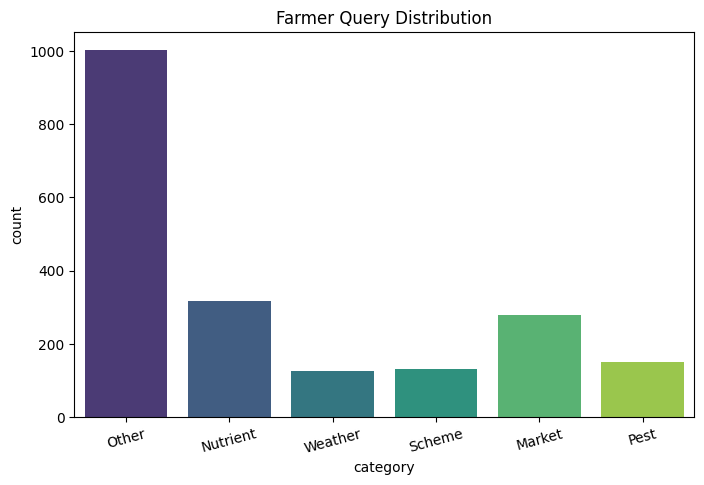

Accuracy: 1.0
              precision    recall  f1-score   support

      Market       1.00      1.00      1.00        59
    Nutrient       1.00      1.00      1.00        65
       Other       1.00      1.00      1.00       201
        Pest       1.00      1.00      1.00        23
      Scheme       1.00      1.00      1.00        23
     Weather       1.00      1.00      1.00        29

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



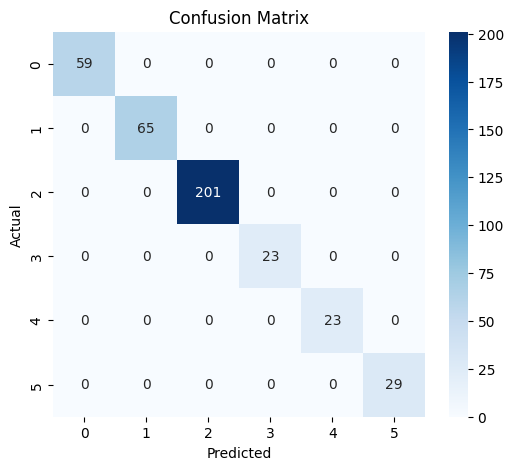

Enter a farmer query: My tomato crop has yellow leaves

Top Similar Queries:

Farmer asked about crop insurance for Tomato?
Farmer asked about crop insurance for Tomato?
Farmer asked about crop insurance for Tomato?
Farmer asked about crop insurance for Tomato?
Farmer asked about market rate of Tomato?
Project completed successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# AI Agriculture Project
# Farmer Query Intelligence System

!pip install pandas scikit-learn matplotlib seaborn nltk

nltk.download('stopwords')

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('raksha-farmer-query.csv')

print(df.head())
print(df.shape)

df.columns = [col.lower() for col in df.columns]

# Correctly identify the column containing the farmer queries
text_column = 'querytext'

# Drop rows where the critical text_column itself has missing values
df.dropna(subset=[text_column], inplace=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df['clean_query'] = df[text_column].apply(clean_text)

def categorize_query(query):

    query = query.lower()

    if 'rain' in query or 'weather' in query:
        return 'Weather'

    elif 'pest' in query or 'disease' in query or 'insect' in query:
        return 'Pest'

    elif 'fertilizer' in query or 'nutrient' in query:
        return 'Nutrient'

    elif 'market' in query or 'price' in query:
        return 'Market'

    elif 'scheme' in query or 'government' in query:
        return 'Scheme'

    else:
        return 'Other'

df['category'] = df['clean_query'].apply(categorize_query)

plt.figure(figsize=(8,5))
sns.countplot(x='category', data=df, palette='viridis')
plt.title('Farmer Query Distribution')
plt.xticks(rotation=15)
plt.show()

X = df['clean_query']
y = df['category']

vectorizer = TfidfVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y,
    test_size=0.2,
    random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

def get_similar_queries(query, top_n=5):

    query_clean = clean_text(query)

    query_vector = vectorizer.transform([query_clean])

    similarity_scores = cosine_similarity(query_vector, X_vectorized)

    similar_indices = similarity_scores.argsort()[0][-top_n:][::-1]

    print("\nTop Similar Queries:\n")

    for idx in similar_indices:
        print(df.iloc[idx][text_column])

new_query = input("Enter a farmer query: ")
get_similar_queries(new_query)

df.to_csv('categorized_farmer_queries.csv', index=False)

print("Project completed successfully.")